###Import Statements

In [17]:
import itertools
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import ast
import json
import csv


In [18]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
### --- Load Dataset (JSON version) --- ###
dataset_path = "/content/drive/MyDrive/Dissertation Work/Research Work/Datasets/large_circuits.json"

# Load JSON into DataFrame
with open(dataset_path, "r") as f:
    data = json.load(f)

df_circuits = pd.DataFrame(data)

# Ensure numvars is int (if missing, infer from variables length)
if "numvars" in df_circuits.columns:
    df_circuits["numvars"] = df_circuits["numvars"].astype(int)
else:
    df_circuits["numvars"] = df_circuits["variables"].apply(len)

# Quick sanity print
for _, row in df_circuits.iterrows():
    print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

hwb7_60 7 166
ham15_107 15 132
sym9_148 10 210
urf2_277 8 3144
bw_291 87 307
ham15_298 45 153
hwb6_301 46 159
hwb7_302 73 281
rd84_313 34 104


In [20]:
# # Ensure numvars is int
# if "numvars" in df_circuits.columns:
#     df_circuits["numvars"] = df_circuits["numvars"].astype(int)
# else:
#     # Fallback if column missing: infer from variables length
#     df_circuits["numvars"] = df_circuits["variables"].apply(len)

# # Quick sanity print
# for _, row in df_circuits.iterrows():
#     print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

###Functions for fault model simulation and fault detection

In [21]:
# ---------- Fault Model ---------- #
def simulate_circuit(circuit, vec):
    """Simulate circuit on a boolean vector.

    Internal gate formats:
      ("TOFFOLI", controls_list, target_idx)
      ("FREDKIN", (controls_list, s1_idx, s2_idx))
    """
    v = vec.copy()
    for gate in circuit:
        gtype = gate[0]
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(v[c] == 1 for c in controls):
                v[target] ^= 1
        elif gtype == "FREDKIN":
            controls_list, s1, s2 = gate[1]
            if all(v[c] == 1 for c in controls_list):
                v[s1], v[s2] = v[s2], v[s1]
        else:
            # Unknown gate type: ignore (or raise if you prefer)
            pass
    return v

In [22]:
# -----------------------
# Fault generation (base-paper: SMGF + SAF at primary inputs)
# -----------------------
def generate_fault_list_base(circuit, n_inputs):
    """
    Returns a list of faults represented as dict:
      - SMGF_i : remove gate i (Missing Gate)
      - SAF_i_v : stuck-at v (0 or 1) at primary input i (simple SAF model)
    NOTE: This SAF model is chosen for base implementation simplicity.
    """
    fault_list = []
    # SMGF (missing-gate faults) - remove gate i
    for i in range(len(circuit)):
        faulty_circuit = circuit[:i] + circuit[i+1:]
        fault_list.append({
            "id": f"SMGF_{i}",
            "type": "SMGF",
            "location": i,
            "circuit": faulty_circuit
        })
    # SAF at primary inputs (Sa0 and Sa1)
    for i in range(n_inputs):
        for v in (0, 1):
            fault_list.append({
                "id": f"SAF_in{i}_S{v}",
                "type": "SAF_INPUT",
                "location": i,
                "val": v
            })
    return fault_list

In [23]:
# -----------------------
# Fault detection (simulate faulty circuit according to fault dict)
# -----------------------
def simulate_with_fault(circuit, vec, fault):
    """Simulate circuit under a given fault and return output vector."""
    ftype = fault["type"]
    if ftype == "SMGF":
        # simulate the faulty circuit (gate removed)
        faulty_circuit = fault["circuit"]
        return simulate_circuit(faulty_circuit, vec)
    elif ftype == "SAF_INPUT":
        # simple stuck-at on primary input: override that input bit with stuck value then simulate
        vec2 = vec.copy()
        loc = fault["location"]
        vec2[loc] = fault["val"]
        return simulate_circuit(circuit, vec2)
    else:
        # Unknown / unsupported in base implementation
        raise ValueError(f"Unsupported fault type: {ftype}")

In [24]:
def detect_fault_simple(cache, circuit, vector, fault):
    """
    Returns True if vector detects the fault (i.e., faulty output != fault-free output).
    Cache keying: (tuple(vec), fault_id)
    """
    vkey = tuple(vector)
    fid = fault["id"]
    key = (vkey, fid)
    if key in cache:
        return cache[key]
    # compute normal output (cache per vector)
    normal_key = ('normal', vkey)
    if normal_key in cache:
        normal_out = cache[normal_key]
    else:
        normal_out = simulate_circuit(circuit, vector)
        cache[normal_key] = normal_out
    # faulty output
    faulty_out = simulate_with_fault(circuit, vector, fault)
    detected = (faulty_out != normal_out)
    cache[key] = detected
    return detected

In [25]:
# -----------------------
# Base-paper fitness for a SINGLE vector
# -----------------------
def fitness_vector(vector, circuit, fault_list, cache=None):
    """
    Fitness = number of faults detected / total faults (returns float in [0,1]).
    cache is a dict to avoid repeated simulation work.
    """
    if cache is None:
        cache = {}
    detected = 0
    for f in fault_list:
        if detect_fault_simple(cache, circuit, vector, f):
            detected += 1
    return detected / len(fault_list) if len(fault_list) > 0 else 0.0

###Fitness Calulation

In [26]:
# -----------------------
# Genetic operators for single-vector chromosomes
# -----------------------
def roulette_select(population, fitnesses):
    total = sum(fitnesses)
    if total == 0:
        return random.choice(population)
    pick = random.uniform(0, total)
    cur = 0.0
    for ind, fit in zip(population, fitnesses):
        cur += fit
        if cur >= pick:
            return ind
    return population[-1]

def single_point_crossover(a, b):
    n = len(a)
    if n <= 1:
        return a.copy(), b.copy()
    point = random.randint(1, n-1)
    c1 = a[:point] + b[point:]
    c2 = b[:point] + a[point:]
    return c1, c2

def bitflip_mutation(ind, pm=0.01):
    n = len(ind)
    out = ind.copy()
    for i in range(n):
        if random.random() < pm:
            out[i] = 1 - out[i]
    return out

###Mutation and Crossover

In [27]:
# -----------------------
# Directed seeding (base-paper): derive seeds from first gate
# -----------------------
def directed_seeds_from_first_gate(circuit, n_inputs):
    seeds = []
    # always include all-zeros and all-ones
    seeds.append([0]*n_inputs)
    seeds.append([1]*n_inputs)
    if len(circuit) == 0:
        # fallback random seeds
        for _ in range(10):
            seeds.append([random.randint(0,1) for _ in range(n_inputs)])
        return seeds
    first_gate = circuit[0]
    if first_gate[0] == "TOFFOLI":
        controls, target = first_gate[1], first_gate[2]
        # generate seeds that activate and deactivate the gate:
        if len(controls) == 0:
            # single-target NOT/Toffoli-like: flip target and keep others random
            for _ in range(5):
                v = [random.randint(0,1) for _ in range(n_inputs)]
                v[target] = 1
                seeds.append(v)
                v2 = v.copy(); v2[target] = 0
                seeds.append(v2)
        else:
            # set all controls = 1 to activate, and 0 to deactivate
            v_on = [0]*n_inputs
            v_off = [0]*n_inputs
            for c in controls:
                v_on[c] = 1
                v_off[c] = 0
            # choose target 0/1 variants
            v_on1 = v_on.copy(); v_on1[target] = 1
            v_on0 = v_on.copy(); v_on0[target] = 0
            seeds.extend([v_on1, v_on0, v_off])
            # also add single control flips for each control
            for c in controls:
                vv = [random.randint(0,1) for _ in range(n_inputs)]
                vv[c] = 1
                seeds.append(vv)
    elif first_gate[0] == "FREDKIN":
        controls, s1, s2 = first_gate[1]
        # produce seeds that make swap active/inactive
        v_on = [0]*n_inputs
        for c in controls:
            v_on[c] = 1
        seeds.append(v_on)
        for _ in range(5):
            vv = [random.randint(0,1) for _ in range(n_inputs)]
            for c in controls:
                vv[c] = 1
            seeds.append(vv)
    else:
        # unknown gate, fallback seeds
        for _ in range(10):
            seeds.append([random.randint(0,1) for _ in range(n_inputs)])
    # deduplicate
    uniq = []
    seen = set()
    for s in seeds:
        t = tuple(s)
        if t not in seen:
            uniq.append(s)
            seen.add(t)
    return uniq

###GA+DP Approach

In [28]:
# -----------------------
# GA (base-paper) implementation — single-vector GA, then combine vectors into test-set
# -----------------------
def run_ga_base(circuit, n_inputs,
                pop_size=50, max_gens=100, pc=0.7, pm=0.01,
                mode="random", stagnation_limit=10, verbose=False):
    """
    Implements the 2018 GA paper's algorithm (random vs directed).
    - mode: "random" or "directed"
    Returns: final_test_set (list of vectors), coverage, stats dict
    """
    fault_list = generate_fault_list_base(circuit, n_inputs)
    total_faults = len(fault_list)
    start_time = time.time()

    # Initialize population of single vectors
    if mode == "random":
        population = [[random.randint(0,1) for _ in range(n_inputs)] for _ in range(pop_size)]
    elif mode == "directed":
        seeds = directed_seeds_from_first_gate(circuit, n_inputs)
        population = []
        # fill population by repeating/perturbing seeds until pop_size
        si = 0
        while len(population) < pop_size:
            base = seeds[si % len(seeds)]
            # small random perturbation
            v = base.copy()
            for i in range(n_inputs):
                if random.random() < 0.05:
                    v[i] = 1 - v[i]
            population.append(v)
            si += 1
    else:
        raise ValueError("mode must be 'random' or 'directed'")

    best_vectors_seen = []   # list of (vector, fitness, detected_fault_ids)
    cache = {}               # simulation cache for detect fault

    best_overall = None
    best_fit = -1.0
    no_improve = 0

    for gen in range(max_gens):
        # evaluate population
        fitnesses = []
        pop_detected_sets = []
        for ind in population:
            # compute fitness (vector-level)
            fit = 0
            detected_set = set()
            # compute per-fault detection
            for f in fault_list:
                if detect_fault_simple(cache, circuit, ind, f):
                    detected_set.add(f["id"])
            fit = len(detected_set) / total_faults if total_faults>0 else 0.0
            fitnesses.append(fit)
            pop_detected_sets.append(detected_set)
            # record top vectors encountered
            best_vectors_seen.append((ind.copy(), fit, detected_set))

        # track best
        gen_best_idx = max(range(len(fitnesses)), key=lambda i: fitnesses[i])
        gen_best_fit = fitnesses[gen_best_idx]
        if gen_best_fit > best_fit:
            best_fit = gen_best_fit
            best_overall = population[gen_best_idx].copy()
            no_improve = 0
        else:
            no_improve += 1

        if verbose:
            print(f"Gen {gen+1}: best_fit={gen_best_fit:.4f} (overall {best_fit:.4f})")

        # termination if full coverage found by single vector
        if best_fit >= 1.0:
            if verbose: print("Single-vector found 100% coverage — terminating early")
            break
        if no_improve >= stagnation_limit:
            if verbose: print("Stagnation reached — terminating")
            break

        # create next generation
        new_pop = []
        # keep elitism: copy top 1
        elite_idx = max(range(len(fitnesses)), key=lambda i: fitnesses[i])
        new_pop.append(population[elite_idx].copy())
        while len(new_pop) < pop_size:
            # selection
            p1 = roulette_select(population, fitnesses)
            p2 = roulette_select(population, fitnesses)
            # crossover with prob pc
            if random.random() < pc:
                c1, c2 = single_point_crossover(p1, p2)
            else:
                c1, c2 = p1.copy(), p2.copy()
            # mutation with pm per bit
            c1 = bitflip_mutation(c1, pm)
            if len(new_pop) < pop_size:
                new_pop.append(c1)
            if len(new_pop) < pop_size:
                c2 = bitflip_mutation(c2, pm)
                new_pop.append(c2)
        population = new_pop

    # --- Combine best vectors encountered into a test-set (greedy union) ---
    # Sort best_vectors_seen by fitness desc and try to add vectors that increase coverage
    best_vectors_seen_sorted = sorted(best_vectors_seen, key=lambda x: x[1], reverse=True)
    final_test_set = []
    covered = set()
    for vec, fit, detected_set in best_vectors_seen_sorted:
        new_fails = detected_set - covered
        if new_fails:
            final_test_set.append(vec.copy())
            covered |= detected_set
        if len(covered) == total_faults:
            break

    # If not full coverage, optionally perform random trials to capture remaining faults (as paper suggests combining strategies)
    if len(covered) < total_faults:
        # try a bounded random search to find vectors that detect remaining faults
        remaining_faults = [f for f in fault_list if f["id"] not in covered]
        for f in remaining_faults:
            found = False
            for _trial in range(200):  # bounded attempts
                candidate = [random.randint(0,1) for _ in range(n_inputs)]
                if detect_fault_simple(cache, circuit, candidate, f):
                    final_test_set.append(candidate)
                    # update covered with all faults this candidate detects
                    for ff in fault_list:
                        if detect_fault_simple(cache, circuit, candidate, ff):
                            covered.add(ff["id"])
                    found = True
                    break
            # if not found, leave it (paper can't guarantee)
    coverage_fraction = len(covered) / total_faults if total_faults>0 else 0.0
    end_time = time.time()
    stats = {
        "generations": gen+1,
        "best_single_vector_fit": best_fit,
        "num_vectors_in_final_set": len(final_test_set),
        "total_faults": total_faults,
        "covered_faults": len(covered),
        "time_sec": round(end_time - start_time, 3)
    }
    return final_test_set, coverage_fraction, stats


###Run over the benchmark circuits

In [29]:
# -----------------------
# Replace run_ga call in earlier run_on_dataset with base GA runner
# -----------------------
def run_on_dataset_base(df, mode="random", save_csv_path="ga_base_results.csv"):
    results = []
    for _, row in df.iterrows():
        variables = row["variables"]
        circuit = convert_dataset_gates(row["gates"], variables)
        n_inputs = int(row["numvars"])
        if not circuit:
            print(f"⚠️ {row['circuit_name']} skipped.")
            continue

        t0 = time.time()
        final_set, coverage, stats = run_ga_base(circuit, n_inputs, pop_size=50, max_gens=100,
                                                pc=0.7, pm=0.01, mode=mode, stagnation_limit=10, verbose=False)
        t1 = time.time()
        exec_time = round(t1 - t0, 2)
        results.append({
            "file": row['circuit_name'],
            "coverage": round(coverage, 4),
            "num_test_vectors": len(final_set),
            "num_gates": len(circuit),
            "exec_time_sec": exec_time,
            "stats": stats,
            "test_vectors": final_set
        })
        print(f"{row['circuit_name']} → coverage={coverage:.4f}, vectors={len(final_set)}, time={exec_time}s")
    # Save summary CSV
    with open(save_csv_path, "w", newline='') as f:
        writer = csv.DictWriter(f, fieldnames=["file","coverage","num_test_vectors","num_gates","exec_time_sec"])
        writer.writeheader()
        for r in results:
            writer.writerow({k: r[k] for k in writer.fieldnames})
    return results

In [30]:
def convert_dataset_gates(dataset_gates, variables):
    """Convert dataset gates (e.g., {'gate':'t3','vars':[...]} or 'f4', etc.)
       into internal tuples for simulator."""
    # Ensure variables is a list (not a string)
    if isinstance(variables, str):
        variables = ast.literal_eval(variables)

    var_map = {v: i for i, v in enumerate(variables)}
    circuit = []

    for g in dataset_gates:
        # Defensive: skip malformed entries
        if not isinstance(g, dict) or "gate" not in g or "vars" not in g:
            continue

        gate_name = str(g["gate"]).lower()   # e.g., 't3', 'f4'
        names = g["vars"]                    # variable names
        # Map names -> indices (skip names not found)
        idxs = [var_map[n] for n in names if n in var_map]
        if len(idxs) == 0:
            continue

        if gate_name.startswith('t'):
            # Toffoli: last is target, others are controls
            if len(idxs) == 1:
                controls, target = [], idxs[0]
            else:
                controls, target = idxs[:-1], idxs[-1]
            circuit.append(("TOFFOLI", controls, target))

        elif gate_name.startswith('f'):
            # Fredkin: last two are swap targets, preceding are controls (can be 0,1, or many)
            if len(idxs) < 2:
                continue
            controls = idxs[:-2]
            s1, s2 = idxs[-2], idxs[-1]
            circuit.append(("FREDKIN", (controls, s1, s2)))

        else:
            # Unknown gate family → ignore (or map to NOT if 1-ary, etc.)
            # If you want NOT: if len(idxs)==1: circuit.append(("TOFFOLI", [], idxs[0]))
            pass

    return circuit

###Visualiza the Results

In [31]:
def plot_gates_coverage_vectors(results):
    files = [r["file"] for r in results]
    num_gates = [r["num_gates"] for r in results]
    coverage = [r["coverage"] for r in results]
    num_vectors = [r["num_test_vectors"] for r in results]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))
    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()
    plt.show()


def plot_coverage_vs_vectors(results):
    x = [r["num_test_vectors"] for r in results]
    y = [r["coverage"] for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=100)
    for i, label in enumerate(labels):
        plt.text(x[i] + 0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_efficiency(results):
    efficiency = [(r["detected_faults"] / r["num_test_vectors"]) if r["num_test_vectors"] else 0 for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(10, 5))
    plt.bar(labels, efficiency)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()

In [56]:
results_random = run_on_dataset_base(df_circuits, mode="random", save_csv_path="/content/drive/MyDrive/Dissertation Work/Research Work/Results/ga_base_random.csv")
results_directed = run_on_dataset_base(df_circuits, mode="directed", save_csv_path="/content/drive/MyDrive/Dissertation Work/Research Work/Results/ga_base_directed.csv")


hwb7_60 → coverage=1.0000, vectors=12, time=3.06s
ham15_107 → coverage=1.0000, vectors=20, time=7.82s
sym9_148 → coverage=1.0000, vectors=11, time=7.27s
urf2_277 → coverage=1.0000, vectors=26, time=1122.85s
bw_291 → coverage=1.0000, vectors=34, time=175.54s
ham15_298 → coverage=1.0000, vectors=30, time=23.82s
hwb6_301 → coverage=1.0000, vectors=35, time=61.46s
hwb7_302 → coverage=1.0000, vectors=44, time=187.46s
rd84_313 → coverage=1.0000, vectors=29, time=15.87s
hwb7_60 → coverage=1.0000, vectors=14, time=0.94s
ham15_107 → coverage=1.0000, vectors=20, time=5.56s
sym9_148 → coverage=1.0000, vectors=11, time=2.98s
urf2_277 → coverage=1.0000, vectors=27, time=1067.04s
bw_291 → coverage=1.0000, vectors=33, time=140.0s
ham15_298 → coverage=1.0000, vectors=27, time=10.54s
hwb6_301 → coverage=1.0000, vectors=38, time=43.24s
hwb7_302 → coverage=1.0000, vectors=53, time=116.7s
rd84_313 → coverage=1.0000, vectors=30, time=17.28s


In [57]:
def plot_faults_per_circuit(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    files = [r["file"] for r in filtered]
    total_faults = [r["total_faults"] for r in filtered]
    detected_faults = [r["detected_faults"] for r in filtered]

    x = np.arange(len(files))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bar1 = ax.bar(x - width/2, total_faults, width, label="Total Faults", color='lightgray')
    bar2 = ax.bar(x + width/2, detected_faults, width, label="Detected Faults", color='mediumseagreen')

    ax.set_xlabel("Circuit")
    ax.set_ylabel("Number of Faults")
    ax.set_title("Total vs Detected Faults per Circuit")
    ax.set_xticks(x)
    ax.set_xticklabels(files, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [58]:
for r in results_random:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')



hwb7_60 → gates: 166, vectors: 12, time: 3.06 sec
ham15_107 → gates: 132, vectors: 20, time: 7.82 sec
sym9_148 → gates: 210, vectors: 11, time: 7.27 sec
urf2_277 → gates: 3144, vectors: 26, time: 1122.85 sec
bw_291 → gates: 307, vectors: 34, time: 175.54 sec
ham15_298 → gates: 153, vectors: 30, time: 23.82 sec
hwb6_301 → gates: 159, vectors: 35, time: 61.46 sec
hwb7_302 → gates: 281, vectors: 44, time: 187.46 sec
rd84_313 → gates: 104, vectors: 29, time: 15.87 sec


In [59]:
for r in results_directed:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')



hwb7_60 → gates: 166, vectors: 14, time: 0.94 sec
ham15_107 → gates: 132, vectors: 20, time: 5.56 sec
sym9_148 → gates: 210, vectors: 11, time: 2.98 sec
urf2_277 → gates: 3144, vectors: 27, time: 1067.04 sec
bw_291 → gates: 307, vectors: 33, time: 140.0 sec
ham15_298 → gates: 153, vectors: 27, time: 10.54 sec
hwb6_301 → gates: 159, vectors: 38, time: 43.24 sec
hwb7_302 → gates: 281, vectors: 53, time: 116.7 sec
rd84_313 → gates: 104, vectors: 30, time: 17.28 sec


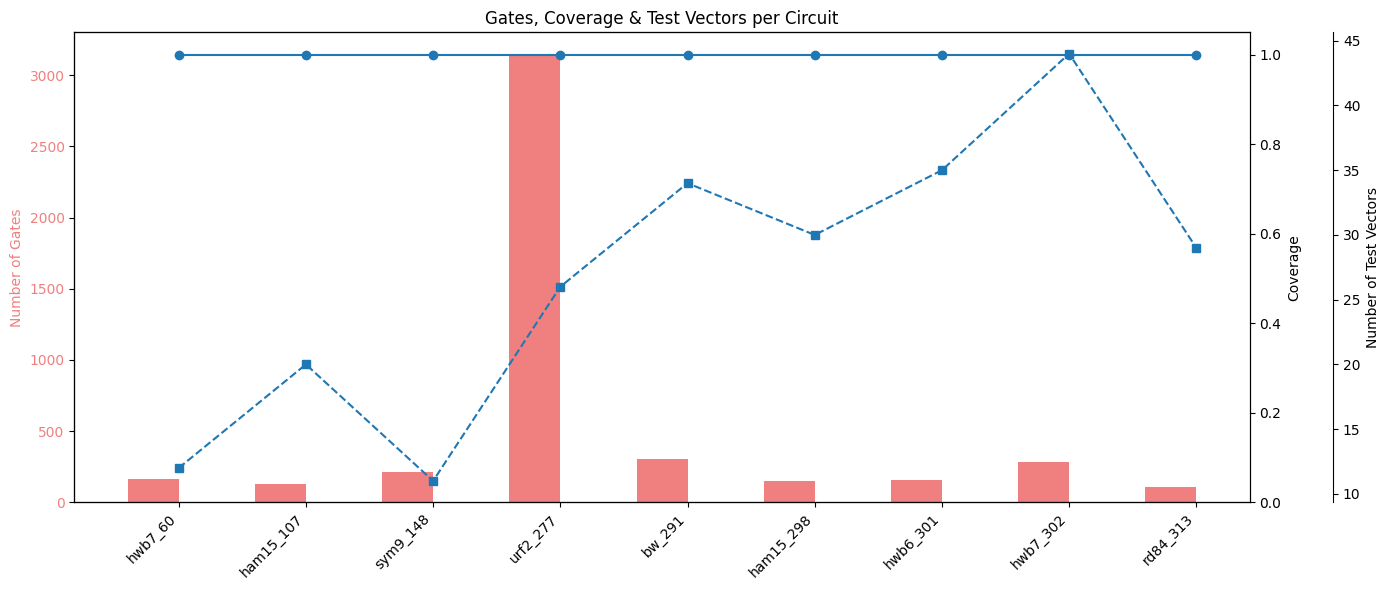

In [60]:
plot_gates_coverage_vectors(results_random)


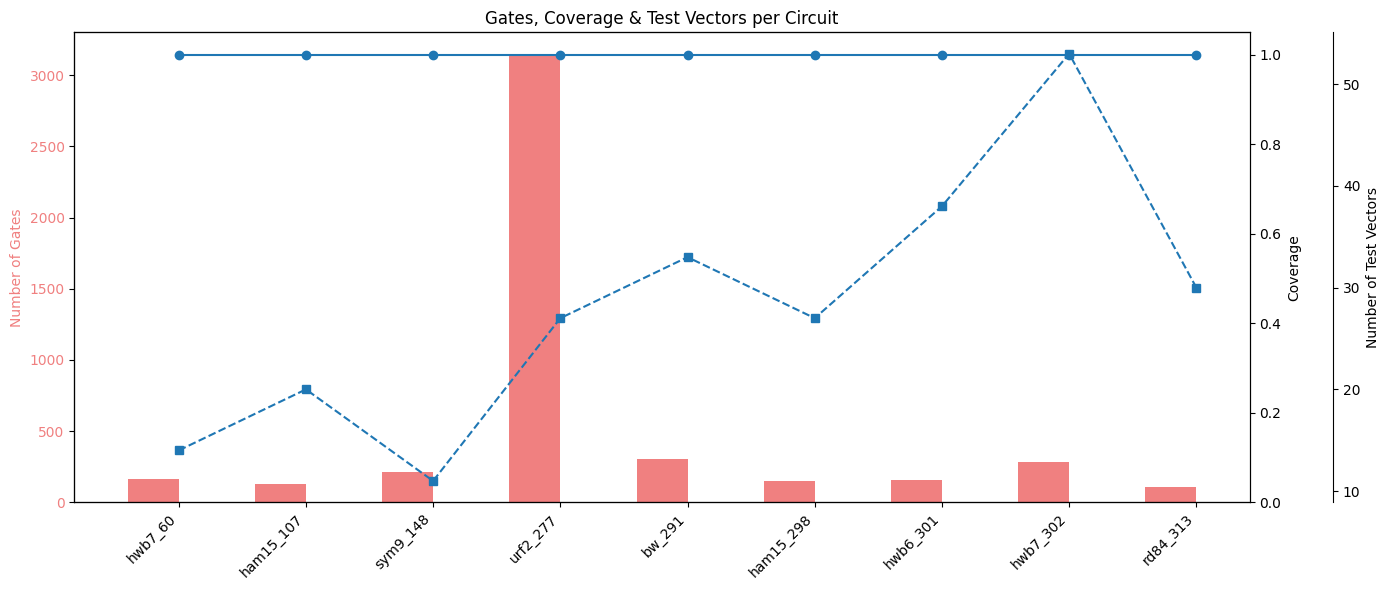

In [61]:
plot_gates_coverage_vectors(results_directed)


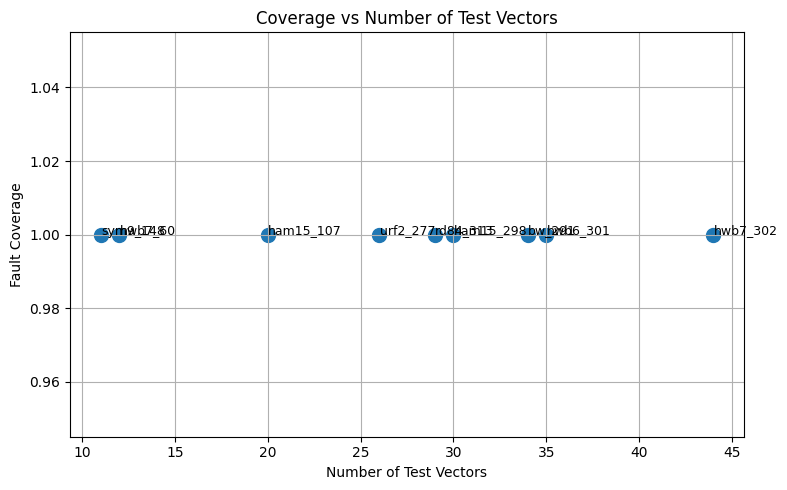

In [62]:
plot_coverage_vs_vectors(results_random)

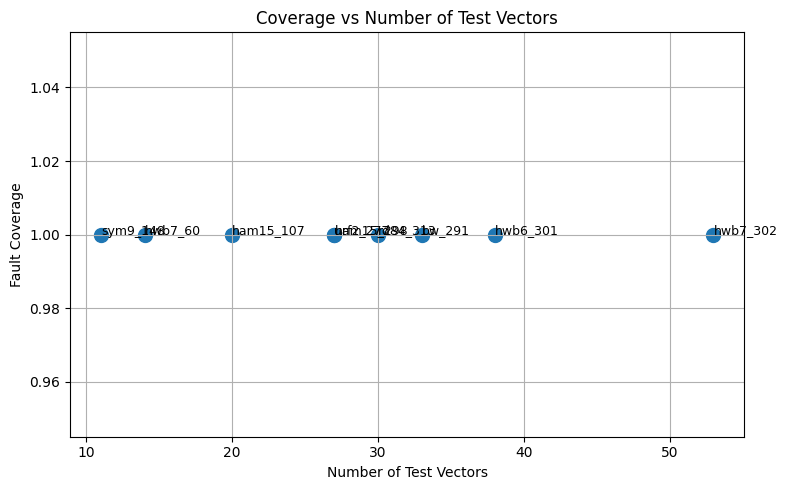

In [63]:
plot_coverage_vs_vectors(results_directed)

In [42]:
plot_efficiency(results_random)
# ---------- Example Execution ---------- #


KeyError: 'detected_faults'

In [43]:
plot_efficiency(results_directed)


KeyError: 'detected_faults'

In [44]:
plot_faults_per_circuit(results_random)


KeyError: 'fitness'

In [45]:
plot_faults_per_circuit(results_directed)


KeyError: 'fitness'